In [ ]:
import pickle
from skyrl_gym.envs.lcb.livecodebench import extract_code_from_model
from general_utils import calculate_cyclomatic_complexity, calculate_halstead_volume, calculate_source_lines_of_code, calculate_unique_variable_count
import pandas as pd


with open("baseline_evaluation.pkl", "rb") as f:
    eval_df = pickle.load(f)

with open("spartan_baseline_evaluation.pkl", "rb") as f:
    spartan_eval_df = pickle.load(f)

eval_df["code"] = eval_df["response"].apply(extract_code_from_model)
spartan_eval_df["code"] = spartan_eval_df["response"].apply(extract_code_from_model)

# Calculate metrics for both dataframes
eval_df["cyclomatic_complexity"] = eval_df["code"].apply(lambda x: calculate_cyclomatic_complexity(x) if x else None)
eval_df["halstead_volume"] = eval_df["code"].apply(lambda x: calculate_halstead_volume(x) if x else None)
eval_df["source_lines_of_code"] = eval_df["code"].apply(lambda x: calculate_source_lines_of_code(x) if x else None)
eval_df["unique_variable_count"] = eval_df["code"].apply(lambda x: calculate_unique_variable_count(x) if x else None)

spartan_eval_df["cyclomatic_complexity"] = spartan_eval_df["code"].apply(lambda x: calculate_cyclomatic_complexity(x) if x else None)
spartan_eval_df["halstead_volume"] = spartan_eval_df["code"].apply(lambda x: calculate_halstead_volume(x) if x else None)
spartan_eval_df["source_lines_of_code"] = spartan_eval_df["code"].apply(lambda x: calculate_source_lines_of_code(x) if x else None)
spartan_eval_df["unique_variable_count"] = spartan_eval_df["code"].apply(lambda x: calculate_unique_variable_count(x) if x else None)

# Determine size of each group (number of responses per prompt)
# Here we assume the number of unique prompts is the grouping factor
eval_size = 279
n = len(eval_df) // eval_size

# Assign group numbers: 0 for first n rows, 1 for next n rows, etc.
eval_df["group_id"] = eval_df.index // n
spartan_eval_df["group_id"] = spartan_eval_df.index // n

# Columns to aggregate with mean
agg_cols = ["reward", "cyclomatic_complexity", "halstead_volume", "source_lines_of_code", "unique_variable_count"]

def aggregate_group(df, agg_cols):
    def group_agg(group):
        result = {'group_id': group.name}
        for col in agg_cols:
            values = group[col]
            # Drop None values, but keep np.nan if present (treat None as missing)
            non_missing = [v for v in values if v is not None]
            # If all are None, output None, else mean (ignoring missing)
            if len(non_missing) == 0:
                result[col] = None
            else:
                # Use pandas to compute mean, will ignore None/nan
                result[col] = pd.Series(non_missing).mean()
        return pd.Series(result)
    return df.groupby("group_id").apply(group_agg).reset_index(drop=True)

eval_df_grouped = aggregate_group(eval_df, agg_cols)
spartan_eval_df_grouped = aggregate_group(spartan_eval_df, agg_cols)

# Filter to only group_ids where halstead_volume is not None in both dataframes
eval_nonnull = eval_df_grouped[eval_df_grouped["halstead_volume"].notna()]
spartan_nonnull = spartan_eval_df_grouped[spartan_eval_df_grouped["halstead_volume"].notna()]

matching_group_ids = set(eval_nonnull["group_id"]).intersection(set(spartan_nonnull["group_id"]))

filtered_eval_df_grouped = eval_df_grouped[eval_df_grouped["group_id"].isin(matching_group_ids)].reset_index(drop=True)
filtered_spartan_eval_df_grouped = spartan_eval_df_grouped[spartan_eval_df_grouped["group_id"].isin(matching_group_ids)].reset_index(drop=True)


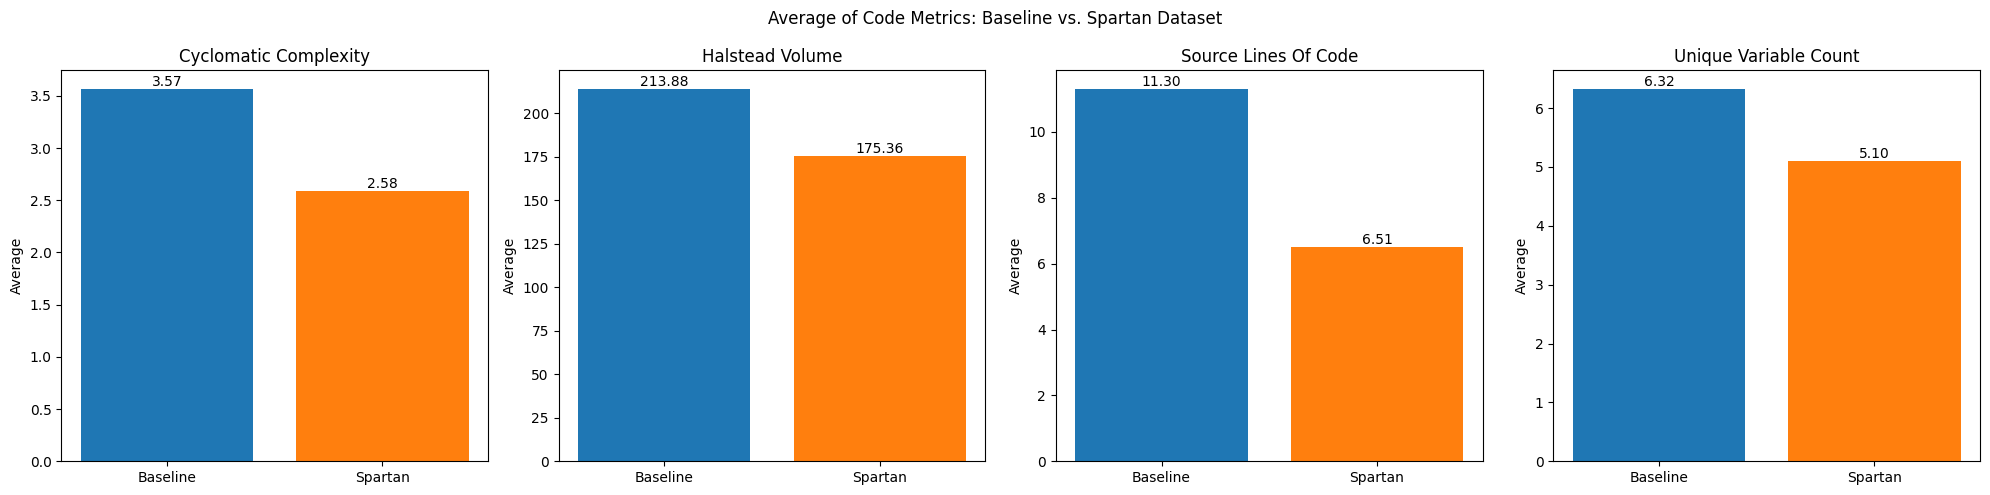

In [8]:
import matplotlib.pyplot as plt


# Define the metrics to plot
metrics = [
    ("cyclomatic_complexity", "Cyclomatic Complexity"),
    ("halstead_volume", "Halstead Volume"),
    ("source_lines_of_code", "Source Lines Of Code"),
    ("unique_variable_count", "Unique Variable Count")
]

# Plot comparison of means for each metric
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (metric, metric_name) in enumerate(metrics):
    avg_eval = filtered_eval_df_grouped[metric].mean()
    avg_spartan = filtered_spartan_eval_df_grouped[metric].mean()
    axs[i].bar(
        ["Baseline", "Spartan"],
        [avg_eval, avg_spartan],
        color=["tab:blue", "tab:orange"]
    )
    axs[i].set_ylabel("Average")
    axs[i].set_title(metric_name)
    axs[i].set_xticks([0, 1])
    axs[i].set_xticklabels(["Baseline", "Spartan"])
    # Show average on top of the bars
    for j, val in enumerate([avg_eval, avg_spartan]):
        axs[i].text(j, val, f"{val:.2f}", ha='center', va='bottom')

plt.suptitle("Average of Code Metrics: Baseline vs. Spartan Dataset")
plt.tight_layout()
plt.show()

In [12]:
eval_df.reward.mean()

np.float64(0.16756272401433692)

In [13]:
spartan_eval_df.reward.mean()

np.float64(0.16196236559139784)